gpqa: kept=8489  dropped(None)=2311 (21.4%)  mean=0.148  median=0.170
hiddenbench: kept=9995  dropped(None)=805 (7.5%)  mean=0.054  median=0.000


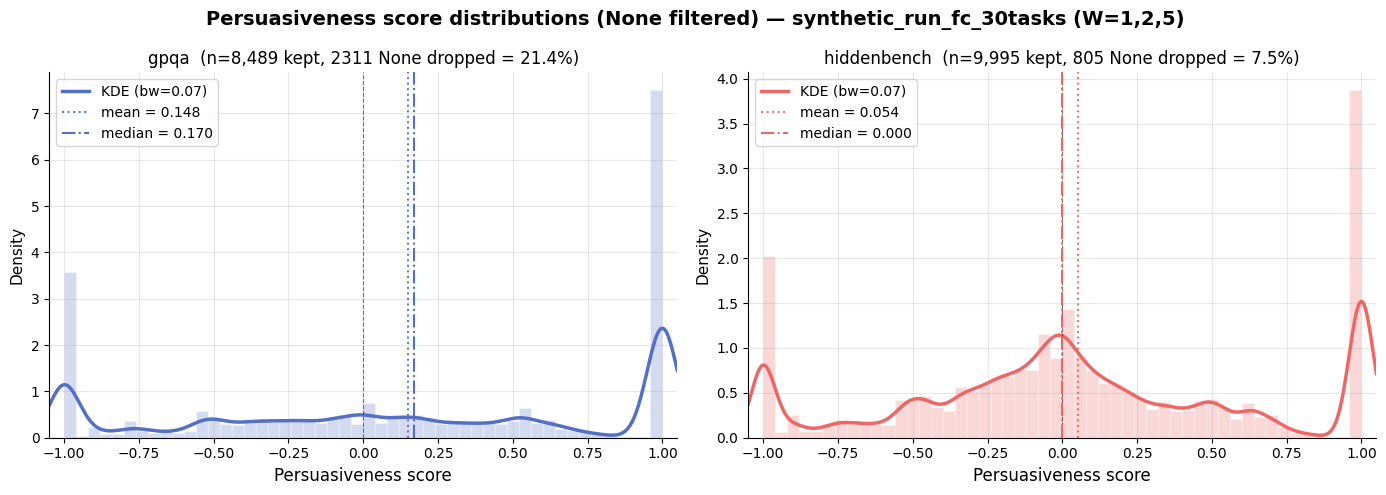

In [13]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import gaussian_kde

from src.metrics.persuasiveness import Persuasiveness

BASE = Path('..') / 'results' / 'mas' / 'synthetic_run_fc_30tasks'
W_VALUES = [1, 2, 5]
DS_COLORS = {'gpqa': '#5470C6', 'hiddenbench': '#EE6666'}

metric = Persuasiveness()

scores_by_ds = {'gpqa': [], 'hiddenbench': []}
none_counts = {'gpqa': 0, 'hiddenbench': 0}
total_counts = {'gpqa': 0, 'hiddenbench': 0}

for w in W_VALUES:
    for f in sorted((BASE / f'W{w}_fc').glob('*.json')):
        d = json.loads(f.read_text())
        ds = d.get('dataset', f.stem.split('_')[0])
        if ds not in scores_by_ds:
            continue
        for rep in d['repetitions']:
            for s in metric.score(rep):
                total_counts[ds] += 1
                if s is None:
                    none_counts[ds] += 1
                else:
                    scores_by_ds[ds].append(s)

for ds, vals in scores_by_ds.items():
    n_total = total_counts[ds]
    n_none = none_counts[ds]
    print(f'{ds}: kept={len(vals)}  dropped(None)={n_none} ({100*n_none/n_total:.1f}%)  mean={np.mean(vals):.3f}  median={np.median(vals):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

xs = np.linspace(-1.05, 1.05, 600)

for ax, ds in zip(axes, ['gpqa', 'hiddenbench']):
    vals = np.array(scores_by_ds[ds])
    color = DS_COLORS[ds]
    n_none = none_counts[ds]
    n_total = total_counts[ds]

    ax.hist(vals, bins=50, density=True, color=color, alpha=0.25, edgecolor='white')

    kde = gaussian_kde(vals, bw_method=0.07)
    ys = kde(xs)
    ax.plot(xs, ys, color=color, linewidth=2.5, label='KDE (bw=0.07)')

    ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axvline(np.mean(vals), color=color, linewidth=1.5, linestyle=':', alpha=0.9,
               label=f'mean = {np.mean(vals):.3f}')
    ax.axvline(np.median(vals), color=color, linewidth=1.5, linestyle='-.',
               label=f'median = {np.median(vals):.3f}')

    ax.set_xlabel('Persuasiveness score', fontsize=12)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(
        f'{ds}  (n={len(vals):,} kept, {n_none} None dropped = {100*n_none/n_total:.1f}%)',
        fontsize=12
    )
    ax.set_xlim(-1.05, 1.05)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Persuasiveness score distributions (None filtered) — synthetic_run_fc_30tasks (W=1,2,5)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

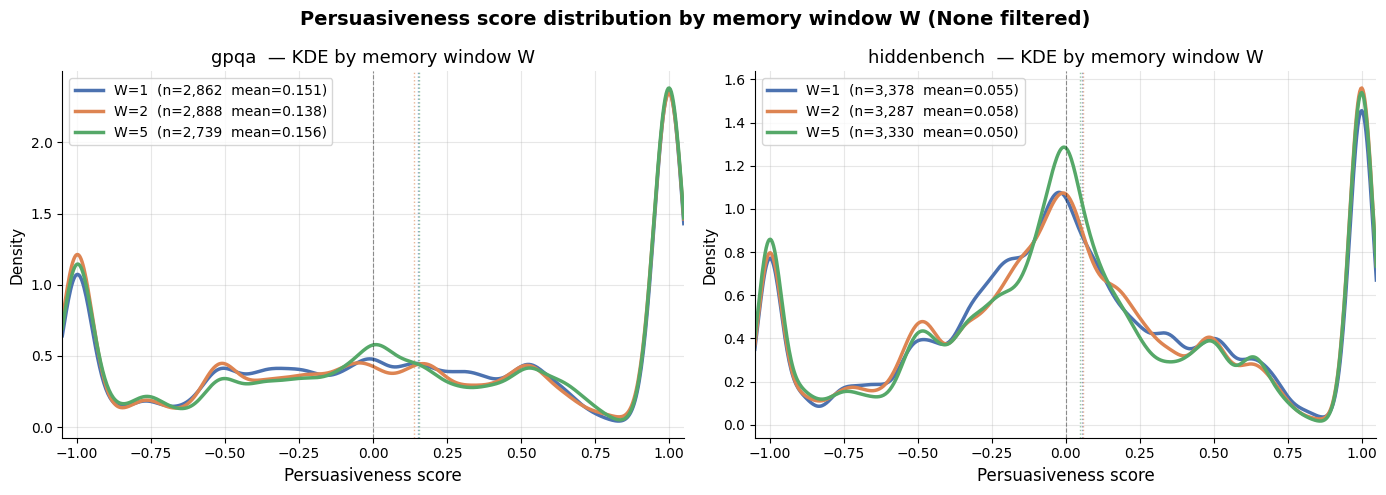

In [15]:
W_COLORS = {1: '#4C72B0', 2: '#DD8452', 5: '#55A868'}

scores_by_ds_w = {ds: {w: [] for w in W_VALUES} for ds in ('gpqa', 'hiddenbench')}

for w in W_VALUES:
    for f in sorted((BASE / f'W{w}_fc').glob('*.json')):
        d = json.loads(f.read_text())
        ds = d.get('dataset', f.stem.split('_')[0])
        if ds not in scores_by_ds_w:
            continue
        for rep in d['repetitions']:
            for s in metric.score(rep):
                if s is not None:
                    scores_by_ds_w[ds][w].append(s)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
xs = np.linspace(-1.05, 1.05, 600)

for ax, ds in zip(axes, ['gpqa', 'hiddenbench']):
    for w in W_VALUES:
        vals = np.array(scores_by_ds_w[ds][w])
        kde = gaussian_kde(vals, bw_method=0.07)
        ax.plot(xs, kde(xs), color=W_COLORS[w], linewidth=2.5,
                label=f'W={w}  (n={len(vals):,}  mean={vals.mean():.3f})')
        ax.axvline(vals.mean(), color=W_COLORS[w], linewidth=1, linestyle=':', alpha=0.6)

    ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.set_xlabel('Persuasiveness score', fontsize=12)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{ds}  — KDE by memory window W', fontsize=13)
    ax.set_xlim(-1.05, 1.05)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Persuasiveness score distribution by memory window W (None filtered)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Rows: 18484  cols: 43

Mean word counts per part:
  message     : 526
  reasoning   : 1047
  defense     : 431
  challenge   : 348
  question    : 266


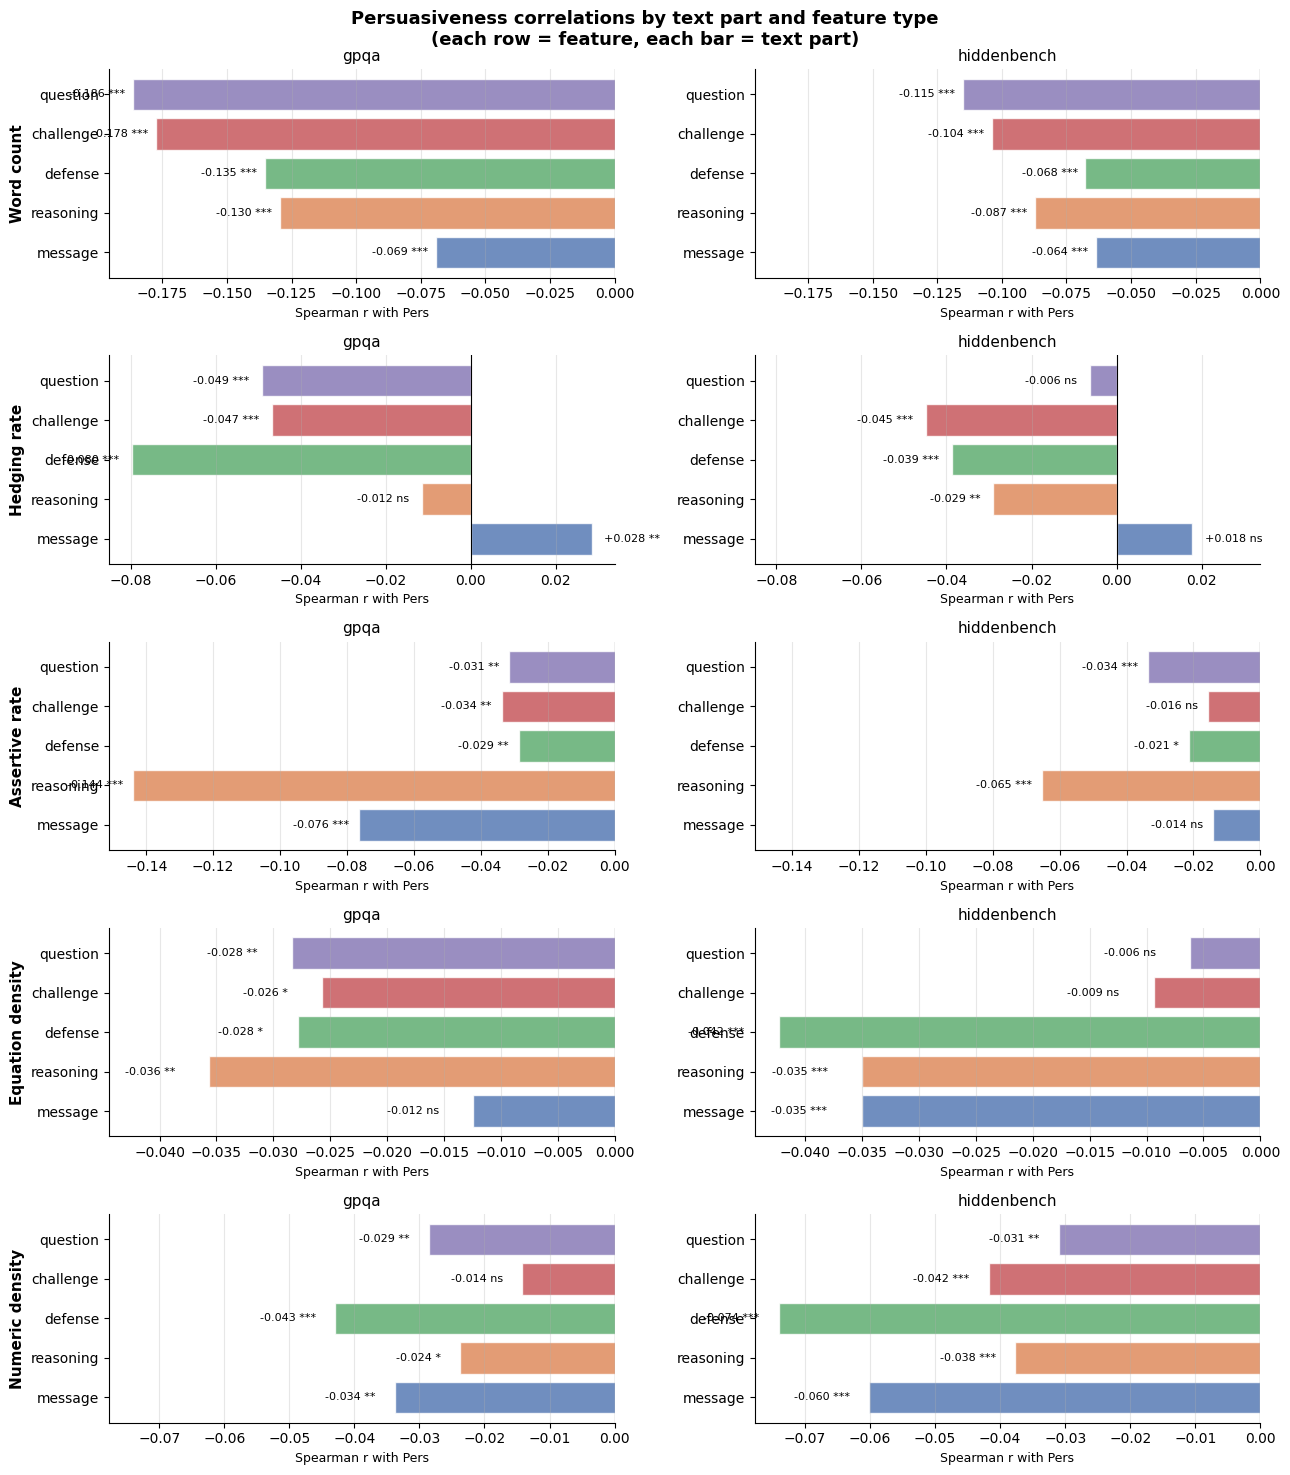

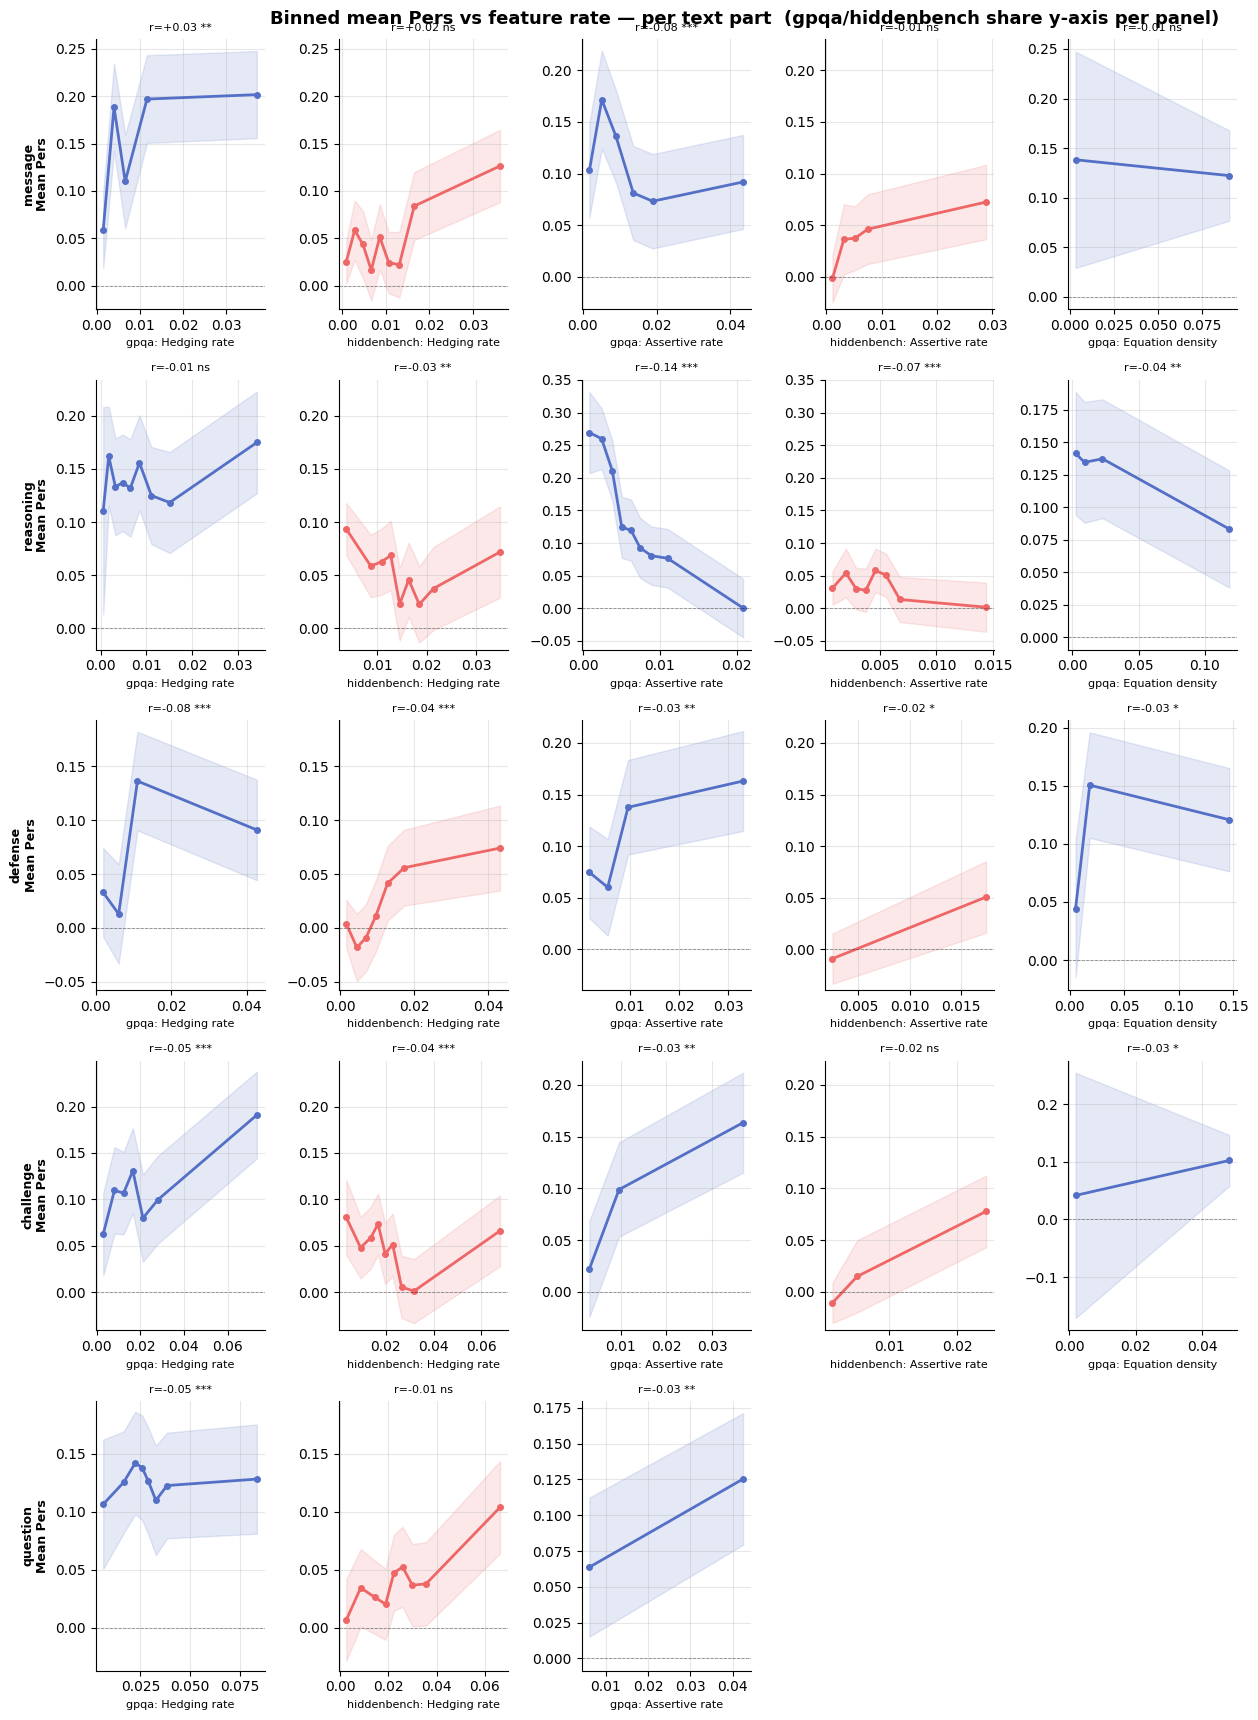

In [29]:
import re
import pandas as pd
from collections import Counter
from scipy import stats as sp_stats

# epistemic uncertainty / tentativeness — higher rate may signal susceptibility to capitulation
HEDGE_RE = re.compile(
    r'\b(however|although|but|yet|while|though|whereas'
    r'|uncertain|unclear|ambiguous|vague|dubious|questionable|doubtful|debatable|contested'
    r'|maybe|perhaps|possibly|potentially|conceivably|presumably|apparently|seemingly|arguably'
    r'|likely|unlikely|probably|tentatively|speculatively'
    r'|might|could|seems|appears|suggests|suppose)\b',
    re.I,
)

# epistemic confidence / declarative force — higher rate may signal persuasive dominance
ASSERT_RE = re.compile(
    r'\b(therefore|thus|hence|consequently|accordingly'
    r'|clearly|obviously|evidently|plainly|undoubtedly|unquestionably|indisputably|categorically'
    r'|must|certainly|definitely|necessarily|invariably|absolutely'
    r'|conclude|demonstrates|proves|establishes|confirms|verifies|shows'
    r'|indeed|explicitly|conclusively|straightforwardly)\b',
    re.I,
)

# mathematical / formal notation — captures equations, LaTeX, unicode math symbols, and fractions;
# signals quantitative / formal reasoning style
EQ_RE = re.compile(
    r'\\\w+'                                   # LaTeX commands: \alpha, \frac, etc.
    r'|\$[^$]+\$'                              # inline math: $x^2$
    r'|[∑∫√×±≈÷∀∃∈∉⊂⊆→⇒↔⊕∝∂∞≠≤≥∇∆]'         # unicode math operators
    r'|\b\d+[\^/]\d+\b',                       # fraction-like: 3/4, 2^n
    re.I,
)

# specific numeric tokens — presence of exact numbers signals use of quantitative evidence
NUM_RE = re.compile(r'\b\d+\.?\d*\b')

PARTS = ('message', 'reasoning', 'defense', 'challenge', 'question')

def text_features(text):
    words = text.split()
    n = max(len(words), 1)
    return {
        'words':  len(words),
        'hedge':  len(HEDGE_RE.findall(text)) / n,
        'assert': len(ASSERT_RE.findall(text)) / n,
        'eq':     len(EQ_RE.findall(text))     / n,
        'num':    len(NUM_RE.findall(text))     / n,
    }

def vote_cfg(votes):
    return '-'.join(map(str, sorted(Counter(votes).values(), reverse=True)))

records = []

for w in W_VALUES:
    for f in sorted((BASE / f'W{w}_fc').glob('*.json')):
        d = json.loads(f.read_text())
        ds = d.get('dataset', f.stem.split('_')[0])
        if ds not in ('gpqa', 'hiddenbench'):
            continue
        gt = d['ground_truth']
        for rep_idx, rep in enumerate(d['repetitions']):
            scores = metric.score(rep)
            traj = rep['trajectory']
            T_orig = len(traj)
            N = len(traj[0]['phase_b'])
            votes_r0    = [traj[0]['phase_b'][a]['vote'] for a in range(N)]
            votes_final = [traj[-1]['phase_b'][a]['vote'] for a in range(N)]
            majority_final = max(set(votes_final), key=votes_final.count)
            rep_correct = majority_final == gt
            cfg = vote_cfg(votes_r0)

            for a in range(N):
                s = scores[a]
                if s is None:
                    continue

                in_majority_r0  = votes_r0.count(votes_r0[a]) > N / 2
                initial_correct = votes_r0[a] == gt
                confs = [traj[t]['phase_b'][a].get('confidence') or 0 for t in range(T_orig)]

                total_pt = total_ct = 0
                part_texts = {p: [] for p in PARTS}
                for step in traj:
                    pb = step['phase_b'][a]
                    total_pt += pb.get('prompt_tokens', 0) or 0
                    total_ct += pb.get('completion_tokens', 0) or 0
                    part_texts['message'].append(pb.get('message', '') or '')
                    part_texts['reasoning'].append(pb.get('reasoning', '') or '')
                    if 'phase_a' in step:
                        pa = step['phase_a'][a]
                        total_pt += pa.get('prompt_tokens', 0) or 0
                        total_ct += pa.get('completion_tokens', 0) or 0
                        for field in ('defense', 'challenge', 'question'):
                            part_texts[field].append(pa.get(field, '') or '')

                part_feats = {p: text_features(' '.join(part_texts[p])) for p in PARTS}

                row = {
                    'score':             s,
                    'ds':               ds,
                    'w':                w,
                    'qid':              d['question_id'],
                    'rep':              rep_idx,
                    'agent':            a,
                    'cfg':              cfg,
                    'rep_correct':      rep_correct,
                    'in_majority_r0':   in_majority_r0,
                    'initial_correct':  initial_correct,
                    'T':               T_orig,
                    'conf_r0':          confs[0],
                    'conf_final':       confs[-1],
                    'conf_mean':        float(np.mean(confs)),
                    'conf_delta':       confs[-1] - confs[0],
                    'prompt_tokens':    total_pt,
                    'completion_tokens': total_ct,
                    'total_tokens':     total_pt + total_ct,
                }
                for p in PARTS:
                    pf = part_feats[p]
                    row[f'{p}_words']  = pf['words']
                    row[f'{p}_hedge']  = pf['hedge']
                    row[f'{p}_assert'] = pf['assert']
                    row[f'{p}_eq']     = pf['eq']
                    row[f'{p}_num']    = pf['num']
                records.append(row)

df_feat = pd.DataFrame(records)
print(f'Rows: {len(df_feat)}  cols: {len(df_feat.columns)}')
print('\nMean word counts per part:')
for p in PARTS:
    print(f'  {p:12s}: {df_feat[f"{p}_words"].mean():.0f}')


FEAT_TYPES = [
    ('words',  'Word count'),
    ('hedge',  'Hedging rate'),
    ('assert', 'Assertive rate'),
    ('eq',     'Equation density'),
    ('num',    'Numeric density'),
]

# keep backward-compatible FEATURES list pointing at message columns (used by downstream cells)
FEATURES = [(f'message_{ft}', f'message {fn}') for ft, fn in FEAT_TYPES]

PART_COLORS = {
    'message':   '#4C72B0',
    'reasoning': '#DD8452',
    'defense':   '#55A868',
    'challenge': '#C44E52',
    'question':  '#8172B2',
}

def spearman_label(x, y):
    r, p = sp_stats.spearmanr(x, y)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    return r, f'r={r:+.2f} {sig}'

# ── Fig 1: per-feature-type bar chart, bars = text parts, panels = datasets ──
n_ft = len(FEAT_TYPES)
fig, axes = plt.subplots(n_ft, 2, figsize=(13, 3 * n_ft), sharey=False)

for row, (ftype, ftitle) in enumerate(FEAT_TYPES):
    for col, ds in enumerate(('gpqa', 'hiddenbench')):
        ax = axes[row, col]
        sub = df_feat[df_feat['ds'] == ds]
        rs, sigs, labels, colors = [], [], [], []
        for p in PARTS:
            r, pv = sp_stats.spearmanr(sub[f'{p}_{ftype}'], sub['score'])
            sig = '***' if pv<0.001 else '**' if pv<0.01 else '*' if pv<0.05 else 'ns'
            rs.append(r); sigs.append(sig); labels.append(p); colors.append(PART_COLORS[p])
        ax.barh(labels, rs, color=colors, alpha=0.8, edgecolor='white')
        ax.axvline(0, color='black', linewidth=0.8)
        for i, (r, sig) in enumerate(zip(rs, sigs)):
            ax.text(r + (0.003 if r >= 0 else -0.003), i, f'{r:+.3f} {sig}',
                    va='center', ha='left' if r >= 0 else 'right', fontsize=8)
        ax.set_xlabel('Spearman r with Pers', fontsize=9)
        if col == 0:
            ax.set_ylabel(ftitle, fontsize=11, fontweight='bold')
        ax.set_title(f'{ds}', fontsize=11)
        ax.grid(axis='x', alpha=0.3)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# share x-axis limits within each feature-type row
for row in range(n_ft):
    xlims = [axes[row, col].get_xlim() for col in range(2)]
    shared = (min(l[0] for l in xlims), max(l[1] for l in xlims))
    for col in range(2):
        axes[row, col].set_xlim(shared)

fig.suptitle('Persuasiveness correlations by text part and feature type\n(each row = feature, each bar = text part)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Fig 2: binned mean — rows=parts, cols=feature×dataset; shared y within each (part, feature) pair ──
PLOT_FTYPES = [('hedge', 'Hedging rate'), ('assert', 'Assertive rate'), ('eq', 'Equation density')]
n_cols = len(PLOT_FTYPES) * 2
fig2, axes2 = plt.subplots(len(PARTS), n_cols,
                           figsize=(5 * len(PLOT_FTYPES), 3.5 * len(PARTS)))

for p_row, part in enumerate(PARTS):
    for f_col, (ftype, ftitle) in enumerate(PLOT_FTYPES):
        pair_axes = []
        for d_off, ds in enumerate(('gpqa', 'hiddenbench')):
            ax = axes2[p_row, f_col * 2 + d_off]
            sub = df_feat[df_feat['ds'] == ds]
            feat_col = f'{part}_{ftype}'
            color = DS_COLORS[ds]
            bins = np.percentile(sub[feat_col], np.linspace(0, 100, 10))
            bins = np.unique(bins)
            if len(bins) < 3:
                ax.set_visible(False); continue
            lbls = (bins[:-1] + bins[1:]) / 2
            cut = pd.cut(sub[feat_col], bins=bins, labels=lbls)
            grp = sub.groupby(cut, observed=False)['score']
            means, sems, ns = grp.mean(), grp.sem(), grp.count()
            valid = ns >= 5
            xs = means.index.astype(float)[valid]
            ax.plot(xs, means[valid], marker='o', color=color, linewidth=2, markersize=4)
            ax.fill_between(xs, (means - sems*1.96)[valid], (means + sems*1.96)[valid],
                            color=color, alpha=0.15)
            ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.4)
            _, rlabel = spearman_label(sub[feat_col], sub['score'])
            ax.set_title(rlabel, fontsize=8)
            ax.set_xlabel(f'{ds}: {ftitle}', fontsize=8)
            if f_col == 0 and d_off == 0:
                ax.set_ylabel(f'{part}\nMean Pers', fontsize=9, fontweight='bold')
            ax.grid(alpha=0.3)
            ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
            pair_axes.append(ax)

        # share y-axis between the two dataset panels for this (part, feature) pair
        if len(pair_axes) == 2:
            ylims = [ax.get_ylim() for ax in pair_axes]
            shared_y = (min(l[0] for l in ylims), max(l[1] for l in ylims))
            for ax in pair_axes:
                ax.set_ylim(shared_y)

fig2.suptitle('Binned mean Pers vs feature rate — per text part  (gpqa/hiddenbench share y-axis per panel)',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Score=+1 or -1 (degenerate):
ds           score
gpqa         -1       1212
              1       2549
hiddenbench  -1        809
              1       1550
Name: score, dtype: int64

Degenerate: 6120 (33.1%)
Inner:      12364 (66.9%)


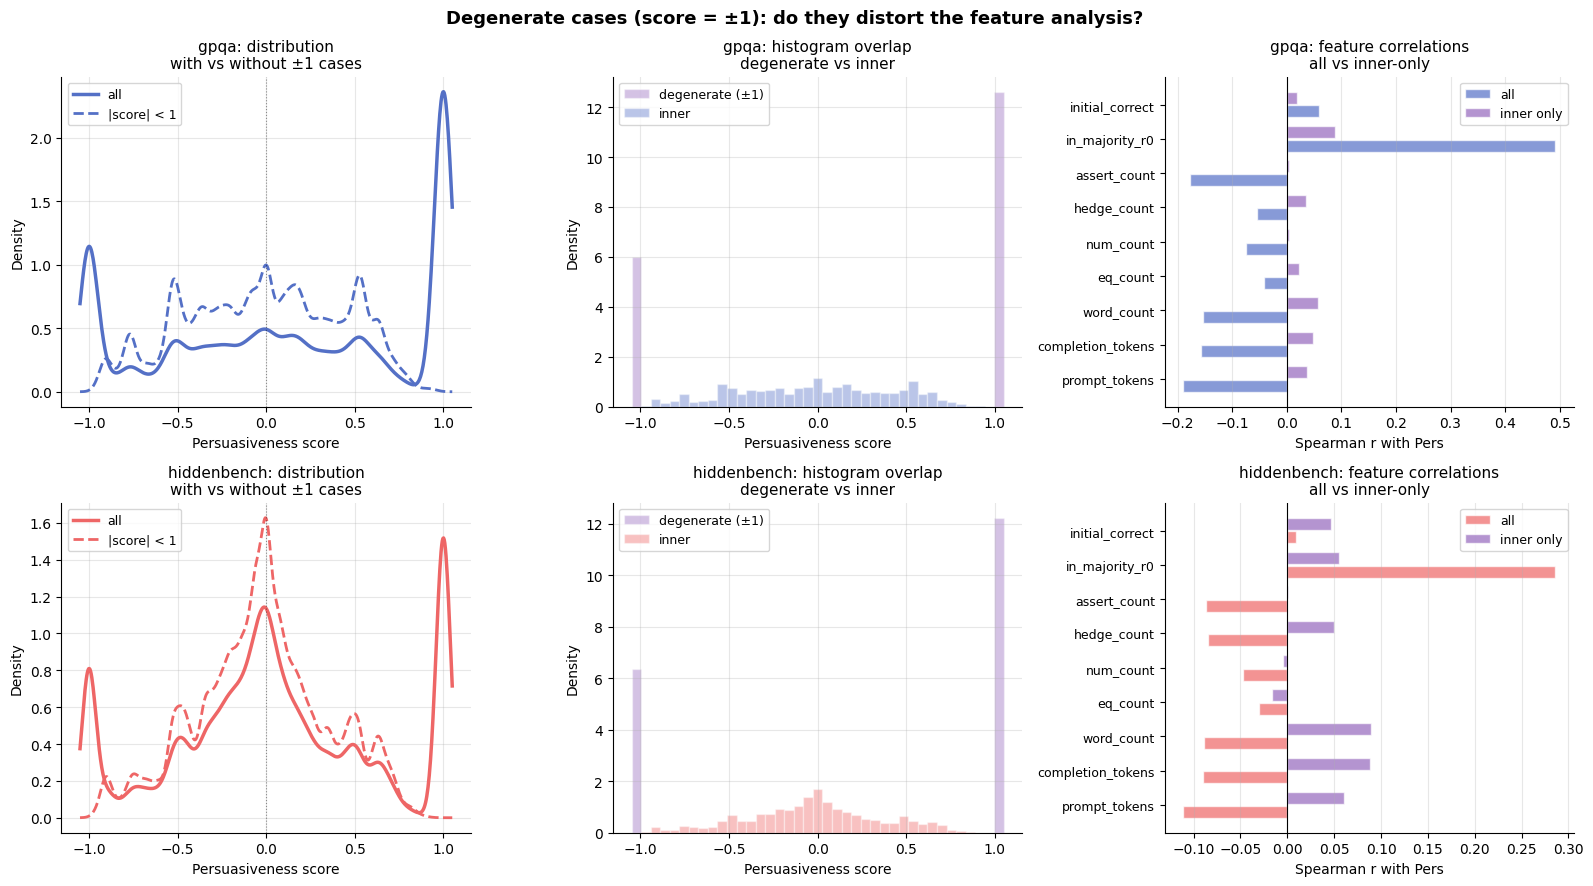


Mean feature values — degenerate vs inner:
ds                          gpqa  hiddenbench
prompt_tokens_degen      17787.7      16346.7
completion_tokens_degen   2391.0       1850.1
word_count_degen          1441.0       1388.0
eq_count_degen              10.7          0.1
num_count_degen            100.0          3.4
hedge_count_degen            4.7         10.4
assert_count_degen           6.5          3.1
prompt_tokens_inner      42455.3      66085.3
completion_tokens_inner   3915.4       4824.2
word_count_inner          2423.7       3698.6
eq_count_inner              20.3          0.2
num_count_inner            163.0          7.0
hedge_count_inner            7.8         26.1
assert_count_inner          11.7          7.4


In [17]:
EPS = 1e-6
df_extreme = df_feat[np.abs(np.abs(df_feat['score']) - 1.0) < EPS].copy()
df_inner   = df_feat[np.abs(np.abs(df_feat['score']) - 1.0) >= EPS].copy()

print('Score=+1 or -1 (degenerate):')
print(df_extreme.groupby(['ds', df_feat.loc[df_extreme.index, 'score'].round(0).astype(int)])['score'].count())
print(f'\nDegenerate: {len(df_extreme)} ({100*len(df_extreme)/len(df_feat):.1f}%)')
print(f'Inner:      {len(df_inner)} ({100*len(df_inner)/len(df_feat):.1f}%)')

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for row, ds in enumerate(('gpqa', 'hiddenbench')):
    color = DS_COLORS[ds]
    sub_all  = df_feat[df_feat['ds'] == ds]
    sub_ext  = df_extreme[df_extreme['ds'] == ds]
    sub_in   = df_inner[df_inner['ds'] == ds]

    ax = axes[row, 0]
    xs = np.linspace(-1.05, 1.05, 600)
    for vals, label, lw, ls in [
        (sub_all['score'].values,  'all',           2.5, '-'),
        (sub_in['score'].values,   '|score| < 1',   2.0, '--'),
    ]:
        kde = gaussian_kde(vals, bw_method=0.07)
        ax.plot(xs, kde(xs), color=color, linewidth=lw, linestyle=ls, label=label)
    ax.axvline(0, color='black', linewidth=0.8, linestyle=':', alpha=0.4)
    ax.set_xlabel('Persuasiveness score', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f'{ds}: distribution\nwith vs without ±1 cases', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    ax = axes[row, 1]
    for vals, label, color_bar in [
        (sub_ext['score'].values, 'degenerate (±1)', '#9467bd'),
        (sub_in['score'].values,  'inner',           color),
    ]:
        bins_h = np.linspace(-1.05, 1.05, 40)
        ax.hist(vals, bins=bins_h, density=True, alpha=0.4, label=label,
                color=color_bar, edgecolor='white')
    ax.set_xlabel('Persuasiveness score', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f'{ds}: histogram overlap\ndegenerate vs inner', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    ax = axes[row, 2]
    feat_names_cmp = [f for f, _ in FEATURES] + ['in_majority_r0', 'initial_correct']
    rs_all, rs_in = [], []
    for feat in feat_names_cmp:
        col_all = sub_all[feat].astype(float) if feat in ('in_majority_r0','initial_correct') else sub_all[feat]
        col_in  = sub_in[feat].astype(float)  if feat in ('in_majority_r0','initial_correct') else sub_in[feat]
        r_all, _ = sp_stats.spearmanr(col_all, sub_all['score'])
        r_in,  _ = sp_stats.spearmanr(col_in,  sub_in['score'])
        rs_all.append(r_all); rs_in.append(r_in)

    y = np.arange(len(feat_names_cmp))
    ax.barh(y - 0.2, rs_all, 0.35, label='all',        color=color,    alpha=0.7, edgecolor='white')
    ax.barh(y + 0.2, rs_in,  0.35, label='inner only',  color='#9467bd', alpha=0.7, edgecolor='white')
    ax.set_yticks(y); ax.set_yticklabels(feat_names_cmp, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Spearman r with Pers', fontsize=10)
    ax.set_title(f'{ds}: feature correlations\nall vs inner-only', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Degenerate cases (score = ±1): do they distort the feature analysis?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nMean feature values — degenerate vs inner:')
print(pd.concat([
    df_extreme.groupby('ds')[[f for f,_ in FEATURES]].mean().add_suffix('_degen'),
    df_inner.groupby('ds')[[f for f,_ in FEATURES]].mean().add_suffix('_inner'),
], axis=1).T.round(1))

In [ ]:
# check if -1 / 1 happens in the first round. if yes, we could maybe drop it. if no, its important

In [18]:
from collections import Counter

EPS = 1e-6

def vote_config(votes):
    counts = sorted(Counter(votes).values(), reverse=True)
    return '-'.join(map(str, counts))

def score_bucket(s):
    if s is None:
        return 'none'
    if abs(s - 1.0) < EPS:
        return '+1'
    if abs(s + 1.0) < EPS:
        return '-1'
    return 'inner'

rows = []
for w in W_VALUES:
    for f in sorted((BASE / f'W{w}_fc').glob('*.json')):
        d = json.loads(f.read_text())
        ds = d.get('dataset', f.stem.split('_')[0])
        if ds not in ('gpqa', 'hiddenbench'):
            continue
        for rep in d['repetitions']:
            traj = rep['trajectory']
            votes_r0 = [ag['vote'] for ag in traj[0]['phase_b']]
            cfg = vote_config(votes_r0)
            scores = metric.score(rep)
            for s in scores:
                rows.append({'ds': ds, 'w': w, 'config': cfg, 'bucket': score_bucket(s)})

df_stat = pd.DataFrame(rows)

def pct_table(group_col):
    buckets = ['none', '-1', 'inner', '+1']
    result = {}
    for (ds, grp), sub in df_stat.groupby(['ds', group_col]):
        total = len(sub)
        result[(ds, grp)] = {b: 100 * (sub['bucket'] == b).sum() / total for b in buckets}
        result[(ds, grp)]['n_agents'] = total
    idx = pd.MultiIndex.from_tuples(result.keys(), names=['dataset', group_col])
    tbl = pd.DataFrame(result.values(), index=idx)
    tbl = tbl[['n_agents', 'none', '-1', 'inner', '+1']]
    tbl.columns = ['n_agents', 'none %', '-1 %', 'inner %', '+1 %']
    return tbl.round(1)


print('=' * 60)
print('TABLE 1 — score bucket breakdown by dataset × memory window')
print('=' * 60)
t1 = pct_table('w')
display(t1.style
    .format({'n_agents': '{:.0f}', 'none %': '{:.1f}', '-1 %': '{:.1f}', 'inner %': '{:.1f}', '+1 %': '{:.1f}'})
    .background_gradient(subset=['inner %'], cmap='Greens')
    .background_gradient(subset=['none %'], cmap='Reds')
    .set_caption('% of agent-scores in each bucket, by dataset and memory window W')
)

print()
print('=' * 60)
print('TABLE 2 — score bucket breakdown by dataset × starting vote config')
print('=' * 60)
CONFIG_ORDER = ['4', '3-1', '2-2', '2-1-1', '1-1-1-1']
t2 = pct_table('config')
t2 = t2.reindex(
    [(ds, cfg) for ds in ('gpqa', 'hiddenbench') for cfg in CONFIG_ORDER if (ds, cfg) in t2.index]
)
display(t2.style
    .format({'n_agents': '{:.0f}', 'none %': '{:.1f}', '-1 %': '{:.1f}', 'inner %': '{:.1f}', '+1 %': '{:.1f}'})
    .background_gradient(subset=['inner %'], cmap='Greens')
    .background_gradient(subset=['none %'], cmap='Reds')
    .set_caption('% of agent-scores in each bucket, by dataset and starting vote configuration')
)

TABLE 1 — score bucket breakdown by dataset × memory window



TABLE 2 — score bucket breakdown by dataset × starting vote config


In [19]:
print('=' * 60)
print('TABLE 3 — score bucket breakdown by dataset × config × W')
print('=' * 60)

buckets = ['none', '-1', 'inner', '+1']
result3 = {}
for (ds, cfg, w), sub in df_stat.groupby(['ds', 'config', 'w']):
    total = len(sub)
    result3[(ds, cfg, w)] = {b: 100 * (sub['bucket'] == b).sum() / total for b in buckets}
    result3[(ds, cfg, w)]['n_agents'] = total

idx3 = pd.MultiIndex.from_tuples(result3.keys(), names=['dataset', 'config', 'W'])
t3 = pd.DataFrame(result3.values(), index=idx3)
t3 = t3[['n_agents', 'none', '-1', 'inner', '+1']]
t3.columns = ['n_agents', 'none %', '-1 %', 'inner %', '+1 %']
t3 = t3.round(1)

ordered_idx = [
    (ds, cfg, w)
    for ds in ('gpqa', 'hiddenbench')
    for cfg in CONFIG_ORDER
    for w in W_VALUES
    if (ds, cfg, w) in t3.index
]
t3 = t3.reindex(ordered_idx)

display(t3.style
    .format({'n_agents': '{:.0f}', 'none %': '{:.1f}', '-1 %': '{:.1f}', 'inner %': '{:.1f}', '+1 %': '{:.1f}'})
    .background_gradient(subset=['inner %'], cmap='Greens', vmin=0, vmax=100)
    .background_gradient(subset=['none %'],  cmap='Reds',   vmin=0, vmax=100)
    .set_caption('% of agent-scores in each bucket, by dataset × starting vote config × memory window W')
)

TABLE 3 — score bucket breakdown by dataset × config × W


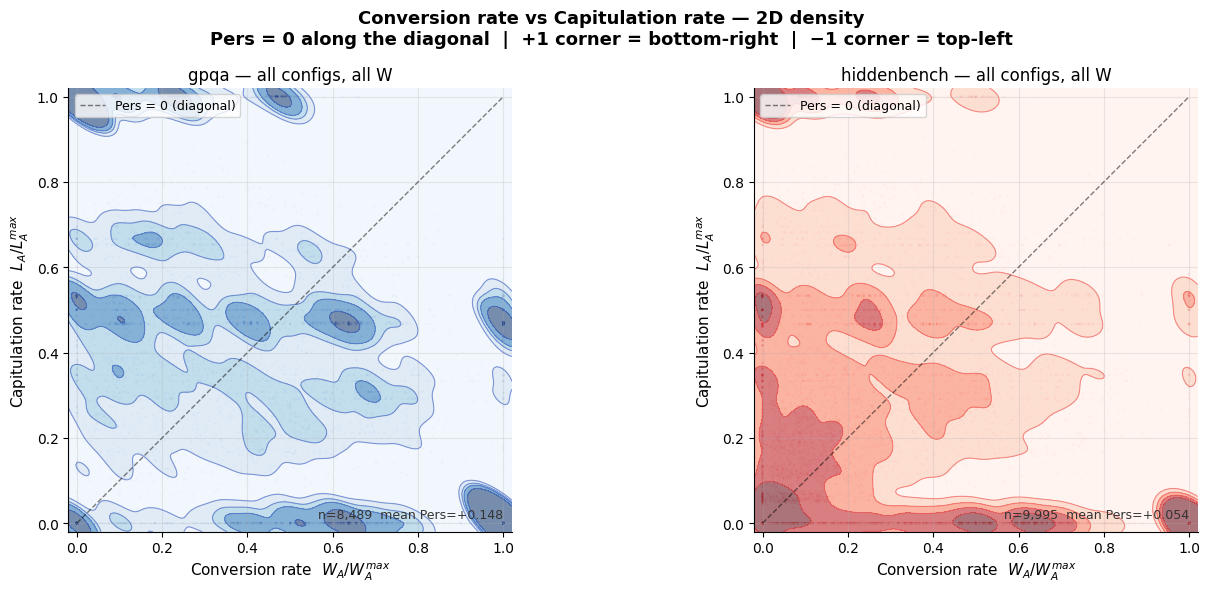

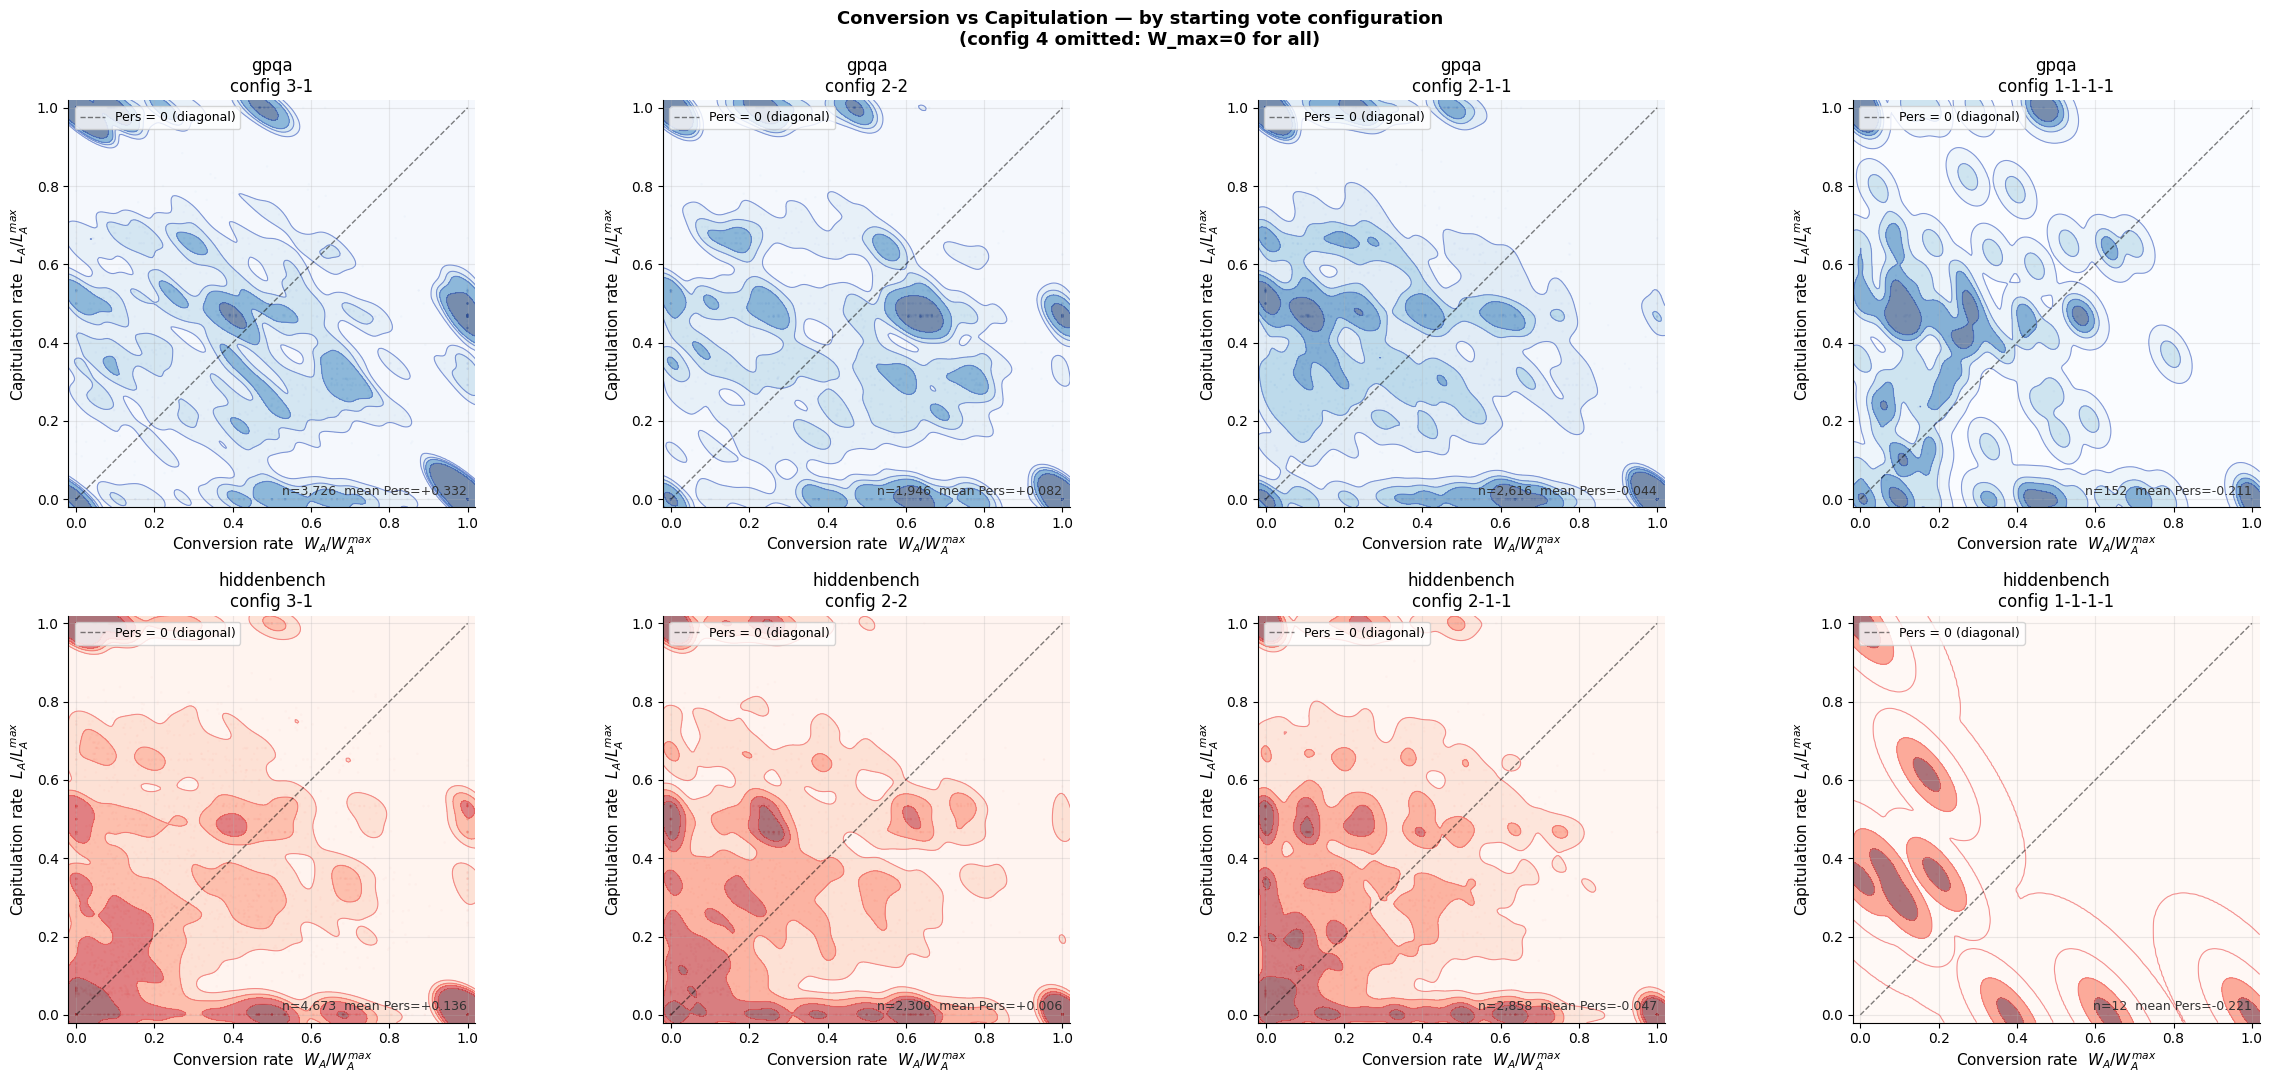

In [20]:
from scipy.stats import gaussian_kde as kde2d

EPS = 1e-6

def collect_conv_cap(filter_ds=None, filter_config=None):
    pts = {'gpqa': {'conv': [], 'cap': [], 'pers': []},
           'hiddenbench': {'conv': [], 'cap': [], 'pers': []}}
    for w in W_VALUES:
        for f in sorted((BASE / f'W{w}_fc').glob('*.json')):
            d = json.loads(f.read_text())
            ds = d.get('dataset', f.stem.split('_')[0])
            if ds not in pts:
                continue
            if filter_ds and ds != filter_ds:
                continue
            for rep in d['repetitions']:
                traj = rep['trajectory']
                votes_r0 = [ag['vote'] for ag in traj[0]['phase_b']]
                cfg = '-'.join(map(str, sorted(Counter(votes_r0).values(), reverse=True)))
                if filter_config and cfg != filter_config:
                    continue
                from src.metrics.persuasiveness import _trim_trailing_unanimous
                traj_t = _trim_trailing_unanimous(traj)
                T = len(traj_t)
                N = len(traj_t[0]['phase_b'])
                for a in range(N):
                    W_a = W_a_max = L_a = L_a_max = 0.0
                    for t in range(T - 1):
                        phase = traj_t[t]['phase_b']
                        next_phase = traj_t[t + 1]['phase_b']
                        v_a = phase[a]['vote']
                        c_a = phase[a].get('confidence') or 0.0
                        m_a = sum(1 for ag in phase if ag['vote'] == v_a)
                        credit = 1.0 / m_a if m_a > 0 else 0.0
                        for b in range(N):
                            if b == a: continue
                            v_b = phase[b]['vote']
                            c_b = phase[b].get('confidence') or 0.0
                            if v_b != v_a:
                                W_a_max += credit * c_b
                                if next_phase[b]['vote'] == v_a:
                                    W_a += credit * c_b
                        L_a_max += c_a
                        if next_phase[a]['vote'] != v_a:
                            L_a += c_a
                    if W_a_max == 0:
                        continue
                    conv = W_a / W_a_max
                    cap  = (L_a / L_a_max) if L_a_max > 0 else 0.0
                    pts[ds]['conv'].append(conv)
                    pts[ds]['cap'].append(cap)
                    pts[ds]['pers'].append(conv - cap)
    return pts


def density_panel(ax, conv, cap, title, color, n_grid=200):
    conv = np.array(conv)
    cap  = np.array(cap)

    ax.scatter(conv, cap, s=3, alpha=0.07, color=color, edgecolors='none', rasterized=True)

    xg = np.linspace(-0.02, 1.02, n_grid)
    yg = np.linspace(-0.02, 1.02, n_grid)
    xx, yy = np.meshgrid(xg, yg)
    pts_grid = np.vstack([xx.ravel(), yy.ravel()])
    k = kde2d(np.vstack([conv, cap]), bw_method=0.08)
    zz = k(pts_grid).reshape(n_grid, n_grid)

    levels = np.percentile(zz[zz > 0], [50, 75, 90, 97])
    ax.contourf(xx, yy, zz, levels=np.concatenate([[0], levels]),
                cmap='Blues' if color == DS_COLORS['gpqa'] else 'Reds', alpha=0.55,
                extend='max')
    ax.contour(xx, yy, zz, levels=levels, colors=color, linewidths=0.8, alpha=0.7)

    diag = np.linspace(0, 1, 200)
    ax.plot(diag, diag, color='black', linewidth=1.0, linestyle='--', alpha=0.5,
            label='Pers = 0 (diagonal)')

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel('Conversion rate  $W_A / W_A^{max}$', fontsize=11)
    ax.set_ylabel('Capitulation rate  $L_A / L_A^{max}$', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_aspect('equal')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    n = len(conv)
    mean_pers = np.mean(conv - cap)
    ax.text(0.98, 0.03, f'n={n:,}  mean Pers={mean_pers:+.3f}',
            transform=ax.transAxes, ha='right', fontsize=9, color='#333333')


pts_all = collect_conv_cap()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, ds in zip(axes, ('gpqa', 'hiddenbench')):
    density_panel(ax, pts_all[ds]['conv'], pts_all[ds]['cap'],
                  f'{ds} — all configs, all W', DS_COLORS[ds])

fig.suptitle('Conversion rate vs Capitulation rate — 2D density\n'
             'Pers = 0 along the diagonal  |  +1 corner = bottom-right  |  −1 corner = top-left',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


CONFIG_ORDER_INNER = ['3-1', '2-2', '2-1-1', '1-1-1-1']
fig2, axes2 = plt.subplots(2, len(CONFIG_ORDER_INNER), figsize=(6 * len(CONFIG_ORDER_INNER), 11))

for row, ds in enumerate(('gpqa', 'hiddenbench')):
    for col, cfg in enumerate(CONFIG_ORDER_INNER):
        pts_cfg = collect_conv_cap(filter_ds=ds, filter_config=cfg)
        conv = pts_cfg[ds]['conv']
        cap  = pts_cfg[ds]['cap']
        ax   = axes2[row, col]
        if len(conv) < 10:
            ax.set_visible(False)
            continue
        density_panel(ax, conv, cap,
                      f'{ds}\nconfig {cfg}', DS_COLORS[ds])

fig2.suptitle('Conversion vs Capitulation — by starting vote configuration\n(config 4 omitted: W_max=0 for all)',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

df_inner: 12364 rows  (dropped 6120 ±1 cases)


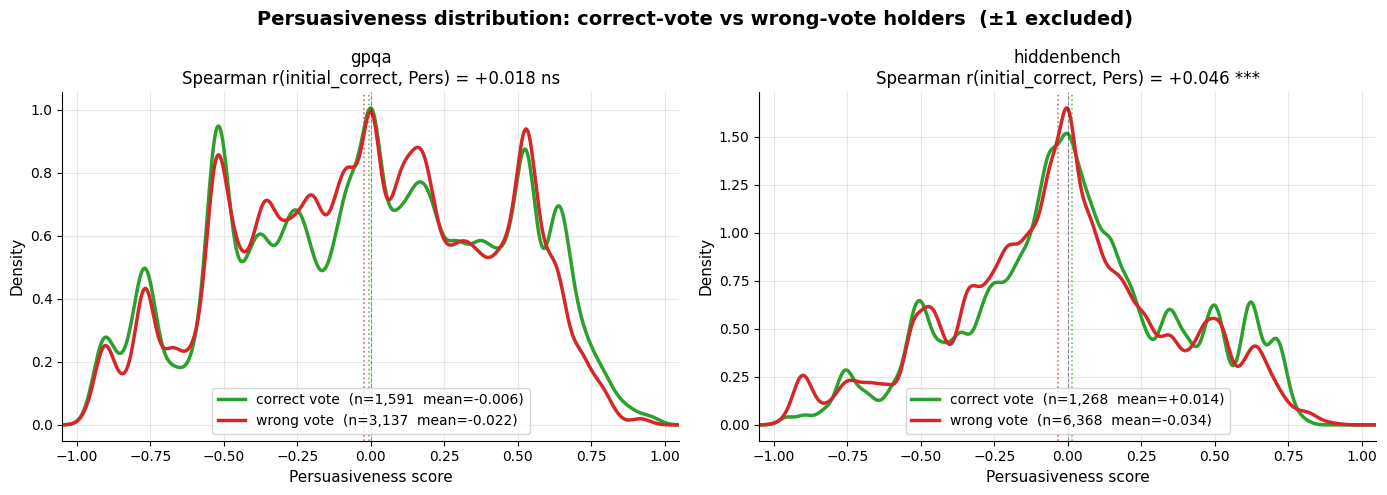

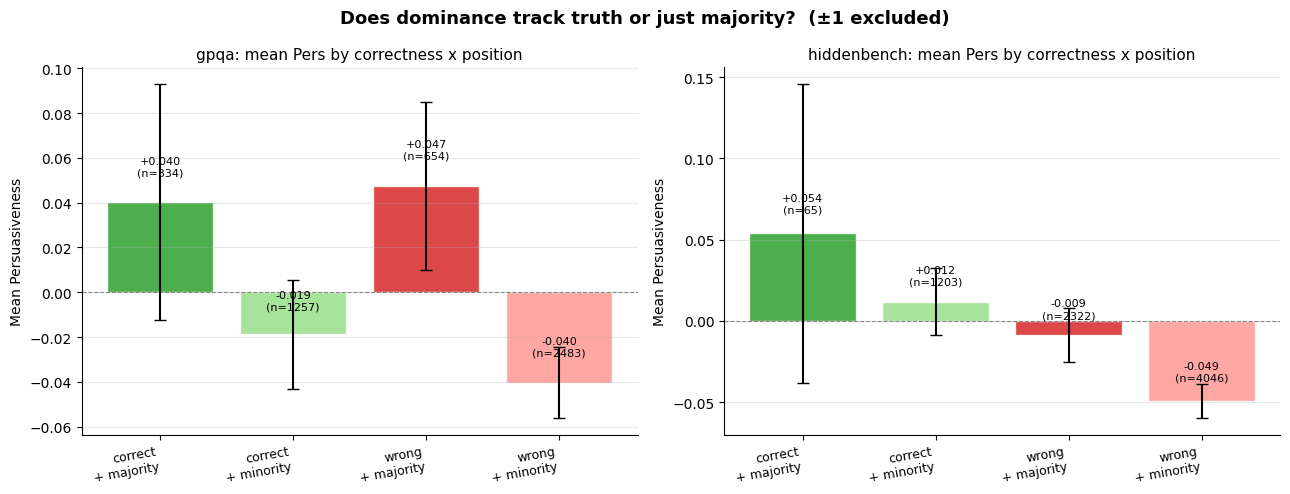

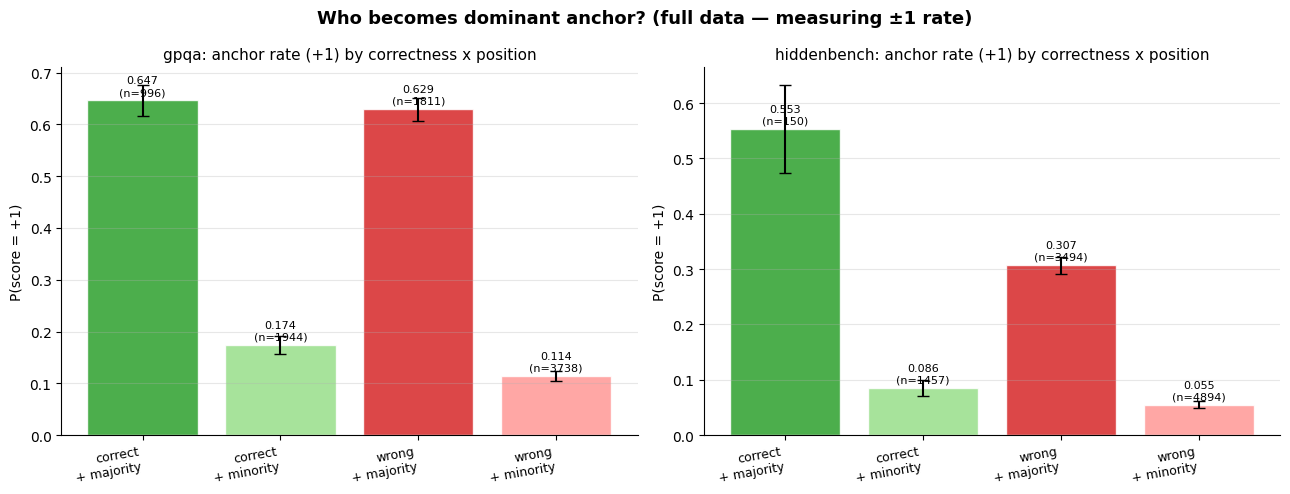

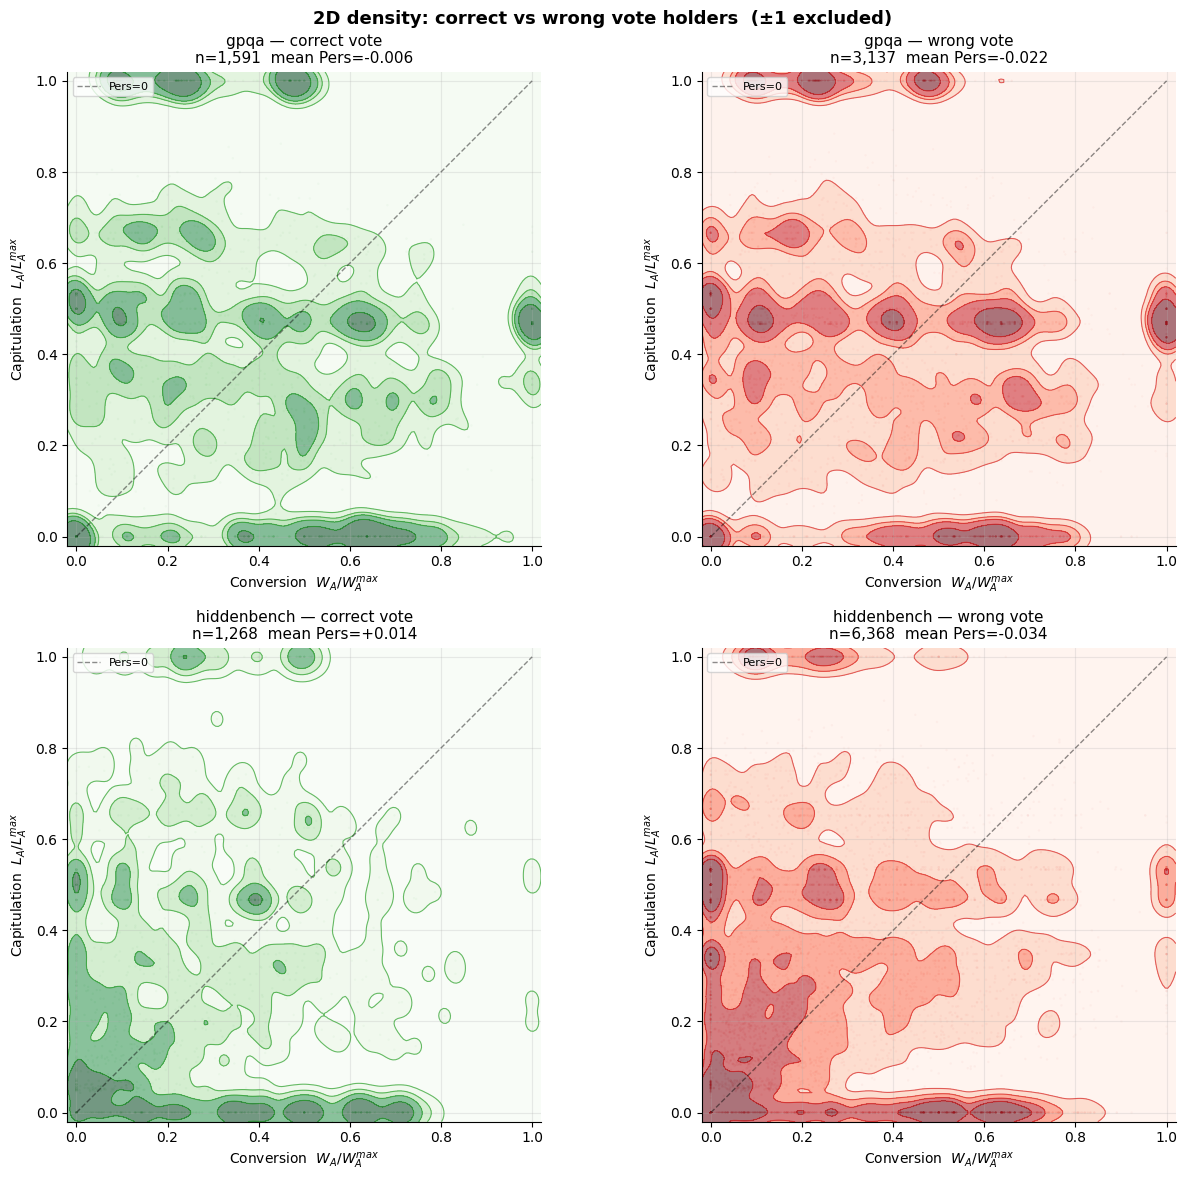

In [21]:
EPS = 1e-6
df_feat['bucket'] = df_feat['score'].apply(
    lambda s: '+1' if abs(s-1)<EPS else ('-1' if abs(s+1)<EPS else 'inner'))
df_inner = df_feat[df_feat['bucket'] == 'inner'].copy()
print(f"df_inner: {len(df_inner)} rows  (dropped {len(df_feat)-len(df_inner)} ±1 cases)")

CORRECT_COLORS = {True: '#2ca02c', False: '#d62728'}
CORRECT_LABELS = {True: 'correct vote', False: 'wrong vote'}
xs = np.linspace(-1.05, 1.05, 600)

# ── Figure 1: KDE split by initial_correct ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ds in zip(axes, ('gpqa', 'hiddenbench')):
    sub = df_inner[df_inner['ds'] == ds]
    r, p = sp_stats.spearmanr(sub['initial_correct'].astype(int), sub['score'])
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    for correct in (True, False):
        vals = sub[sub['initial_correct'] == correct]['score'].values
        kde = gaussian_kde(vals, bw_method=0.07)
        ax.plot(xs, kde(xs), color=CORRECT_COLORS[correct], linewidth=2.5,
                label=f'{CORRECT_LABELS[correct]}  (n={len(vals):,}  mean={vals.mean():+.3f})')
        ax.axvline(vals.mean(), color=CORRECT_COLORS[correct], linewidth=1.2, linestyle=':', alpha=0.7)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.set_xlabel('Persuasiveness score', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{ds}\nSpearman r(initial_correct, Pers) = {r:+.3f} {sig}', fontsize=12)
    ax.set_xlim(-1.05, 1.05)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig.suptitle('Persuasiveness distribution: correct-vote vs wrong-vote holders  (±1 excluded)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Figure 2: mean Pers by correctness x majority ──
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
GROUPS = [
    (True,  True,  'correct\n+ majority', '#2ca02c'),
    (True,  False, 'correct\n+ minority', '#98df8a'),
    (False, True,  'wrong\n+ majority',   '#d62728'),
    (False, False, 'wrong\n+ minority',   '#ff9896'),
]
for ax, ds in zip(axes2, ('gpqa', 'hiddenbench')):
    sub = df_inner[df_inner['ds'] == ds]
    for corr, maj, label, color in GROUPS:
        g = sub[(sub['initial_correct']==corr) & (sub['in_majority_r0']==maj)]
        if len(g) < 5: continue
        val = g['score'].mean(); err = g['score'].sem() * 1.96
        ax.bar(label, val, color=color, alpha=0.85, edgecolor='white')
        ax.errorbar(label, val, yerr=err, fmt='none', color='black', capsize=4)
        ax.text(label, val + (abs(val)*0.05+0.01), f'{val:+.3f}\n(n={len(g)})',
                ha='center', fontsize=8)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.set_ylabel('Mean Persuasiveness', fontsize=10)
    ax.set_title(f'{ds}: mean Pers by correctness x position', fontsize=11)
    plt.setp(ax.get_xticklabels(), rotation=10, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig2.suptitle('Does dominance track truth or just majority?  (±1 excluded)',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Figure 3: anchor rate by correctness x majority (uses full df_feat — we ARE measuring who gets ±1) ──
fig3, axes3 = plt.subplots(1, 2, figsize=(13, 5))
for ax, ds in zip(axes3, ('gpqa', 'hiddenbench')):
    sub = df_feat[df_feat['ds'] == ds]
    for corr, maj, label, color in GROUPS:
        g = sub[(sub['initial_correct']==corr) & (sub['in_majority_r0']==maj)]
        if len(g) < 5: continue
        val = (g['bucket']=='+1').mean()
        err = np.sqrt(val*(1-val)/len(g)) * 1.96
        ax.bar(label, val, color=color, alpha=0.85, edgecolor='white')
        ax.errorbar(label, val, yerr=err, fmt='none', color='black', capsize=4)
        ax.text(label, val+0.01, f'{val:.3f}\n(n={len(g)})', ha='center', fontsize=8)
    ax.set_ylabel('P(score = +1)', fontsize=10)
    ax.set_title(f'{ds}: anchor rate (+1) by correctness x position', fontsize=11)
    plt.setp(ax.get_xticklabels(), rotation=10, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig3.suptitle('Who becomes dominant anchor? (full data — measuring ±1 rate)',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Figure 4: 2D conv/cap split by correctness (inner only) ──
rows_cc = []
for w in W_VALUES:
    for f in sorted((BASE / f'W{w}_fc').glob('*.json')):
        d = json.loads(f.read_text())
        ds = d.get('dataset', f.stem.split('_')[0])
        if ds not in ('gpqa', 'hiddenbench'): continue
        gt = d['ground_truth']
        for rep in d['repetitions']:
            from src.metrics.persuasiveness import _trim_trailing_unanimous
            traj = rep['trajectory']
            votes_r0 = [ag['vote'] for ag in traj[0]['phase_b']]
            traj_t = _trim_trailing_unanimous(traj)
            T = len(traj_t); N = len(traj_t[0]['phase_b'])
            for a in range(N):
                W_a = W_a_max = L_a = L_a_max = 0.0
                for t in range(T - 1):
                    phase = traj_t[t]['phase_b']; nxt = traj_t[t+1]['phase_b']
                    v_a = phase[a]['vote']; c_a = phase[a].get('confidence') or 0.0
                    m_a = sum(1 for ag in phase if ag['vote'] == v_a)
                    credit = 1.0 / m_a if m_a > 0 else 0.0
                    for b in range(N):
                        if b == a: continue
                        v_b = phase[b]['vote']; c_b = phase[b].get('confidence') or 0.0
                        if v_b != v_a:
                            W_a_max += credit * c_b
                            if nxt[b]['vote'] == v_a: W_a += credit * c_b
                    L_a_max += c_a
                    if nxt[a]['vote'] != v_a: L_a += c_a
                if W_a_max == 0: continue
                conv = W_a / W_a_max
                cap  = (L_a / L_a_max) if L_a_max > 0 else 0.0
                pers = conv - cap
                if abs(abs(pers) - 1.0) < EPS: continue  # exclude ±1
                rows_cc.append({'ds': ds, 'conv': conv, 'cap': cap,
                                'initial_correct': votes_r0[a] == gt})

df_cc = pd.DataFrame(rows_cc)
fig4, axes4 = plt.subplots(2, 2, figsize=(13, 12))
for row, ds in enumerate(('gpqa', 'hiddenbench')):
    sub = df_cc[df_cc['ds'] == ds]
    for col, correct in enumerate((True, False)):
        ax = axes4[row, col]; s = sub[sub['initial_correct'] == correct]
        color = CORRECT_COLORS[correct]; cmap = 'Greens' if correct else 'Reds'
        ax.scatter(s['conv'], s['cap'], s=3, alpha=0.07, color=color, edgecolors='none', rasterized=True)
        if len(s) >= 20:
            xg = np.linspace(-0.02, 1.02, 180); yg = np.linspace(-0.02, 1.02, 180)
            xx, yy = np.meshgrid(xg, yg)
            k = kde2d(np.vstack([s['conv'].values, s['cap'].values]), bw_method=0.08)
            zz = k(np.vstack([xx.ravel(), yy.ravel()])).reshape(180, 180)
            levels = np.percentile(zz[zz > 0], [50, 75, 90, 97])
            ax.contourf(xx, yy, zz, levels=np.concatenate([[0], levels]),
                        cmap=cmap, alpha=0.55, extend='max')
            ax.contour(xx, yy, zz, levels=levels, colors=color, linewidths=0.8, alpha=0.7)
        ax.plot(np.linspace(0,1,200), np.linspace(0,1,200), 'k--', linewidth=1.0, alpha=0.45, label='Pers=0')
        ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
        ax.set_xlabel('Conversion  $W_A/W_A^{max}$', fontsize=10)
        ax.set_ylabel('Capitulation  $L_A/L_A^{max}$', fontsize=10)
        mean_p = (s['conv'] - s['cap']).mean()
        ax.set_title(f'{ds} — {CORRECT_LABELS[correct]}\nn={len(s):,}  mean Pers={mean_p:+.3f}', fontsize=11)
        ax.set_aspect('equal'); ax.legend(fontsize=8, loc='upper left')
        ax.grid(alpha=0.25); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig4.suptitle('2D density: correct vs wrong vote holders  (±1 excluded)',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Rep-level rows: 3422  (±1 excluded at agent level before aggregation)


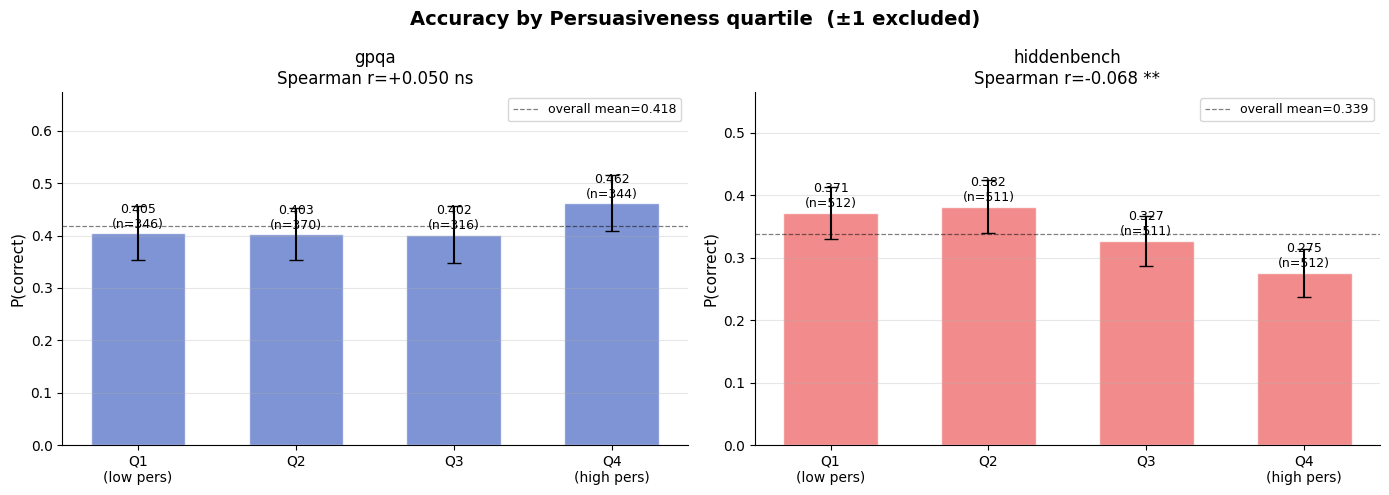

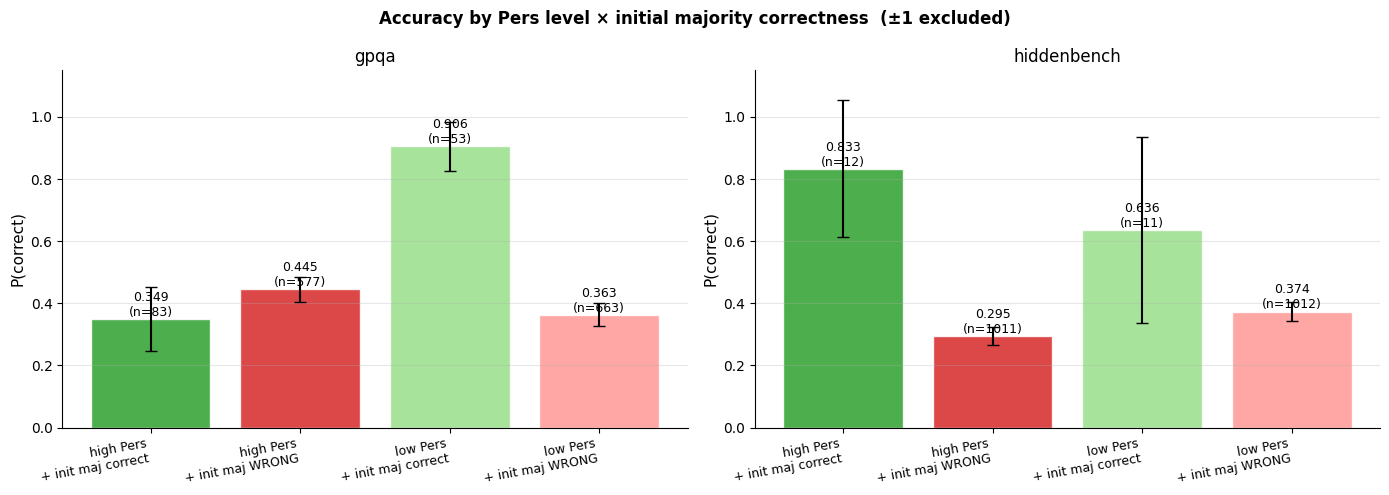

gpqa:  high-pers net=+0.308  low-pers net=+0.330
hiddenbench:  high-pers net=+0.289  low-pers net=+0.366


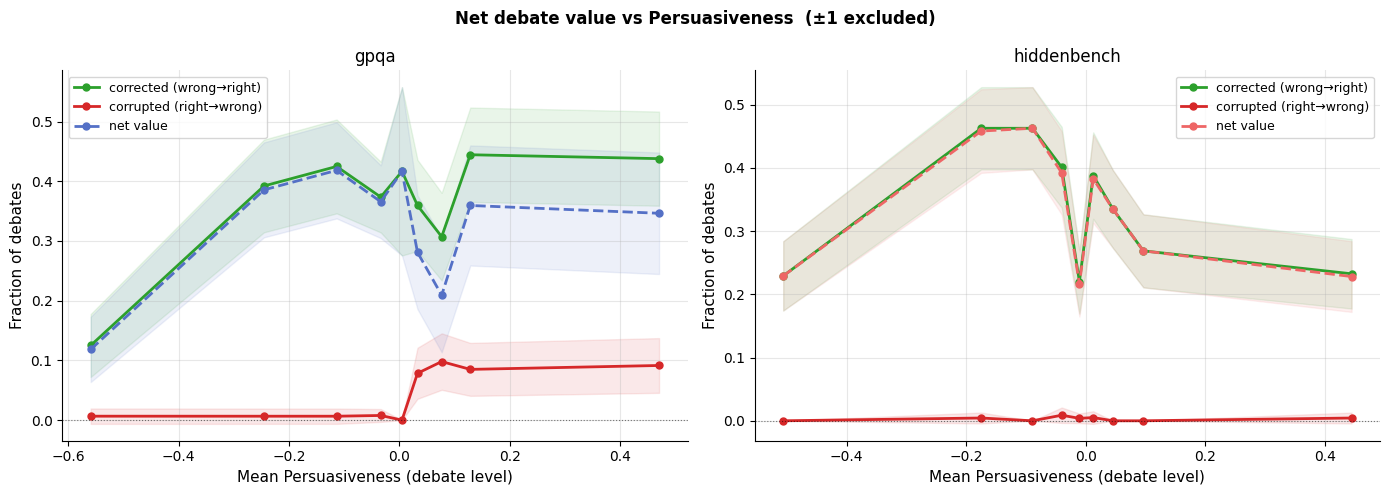

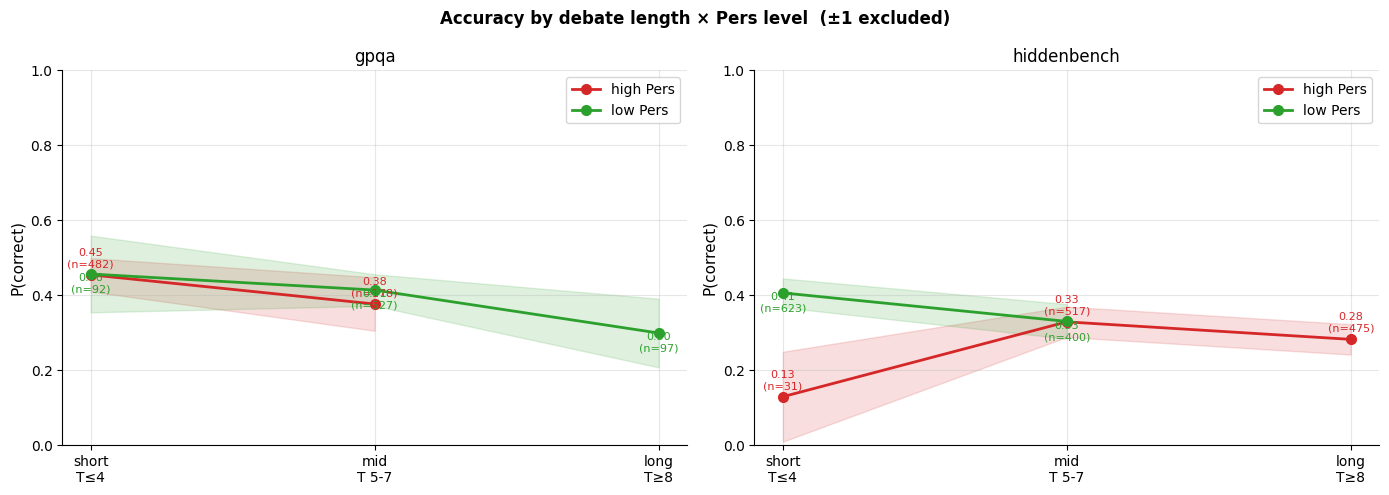

In [22]:
EPS = 1e-6
df_feat['bucket'] = df_feat['score'].apply(
    lambda s: '+1' if abs(s-1)<EPS else ('-1' if abs(s+1)<EPS else 'inner'))
df_inner = df_feat[df_feat['bucket'] == 'inner'].copy()

rep_df = df_inner.groupby(['ds','w','qid','rep']).agg(
    pers_mean=('score','mean'),
    pers_max=('score','max'),
    pers_spread=('score', lambda x: x.max()-x.min()),
    rep_correct=('rep_correct','first'),
    T=('T','first'),
    cfg=('cfg','first'),
).reset_index()

maj_correct_rep = df_inner.groupby(['ds','w','qid','rep']).apply(
    lambda x: (x['in_majority_r0'] & x['initial_correct']).any(),
    include_groups=False
).reset_index(name='init_majority_correct')
rep_df = rep_df.merge(maj_correct_rep, on=['ds','w','qid','rep'])
rep_df['corrected'] = (~rep_df['init_majority_correct']) & rep_df['rep_correct']
rep_df['corrupted'] =  rep_df['init_majority_correct']  & (~rep_df['rep_correct'])
rep_df['net_value'] = rep_df['corrected'].astype(int) - rep_df['corrupted'].astype(int)
print(f"Rep-level rows: {len(rep_df)}  (±1 excluded at agent level before aggregation)")


# ── Figure 1: Accuracy by Pers quartile ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ds in zip(axes, ('gpqa', 'hiddenbench')):
    sub = rep_df[rep_df['ds'] == ds].copy()
    r, p = sp_stats.spearmanr(sub['pers_mean'], sub['rep_correct'])
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    sub['q'] = pd.qcut(sub['pers_mean'], 4, labels=['Q1\n(low pers)','Q2','Q3','Q4\n(high pers)'])
    grp = sub.groupby('q', observed=True)['rep_correct']
    means, sems = grp.mean(), grp.sem()
    color = DS_COLORS[ds]
    xs = range(len(means))
    ax.bar(xs, means.values, color=color, alpha=0.75, edgecolor='white', width=0.6)
    ax.errorbar(xs, means.values, yerr=sems.values*1.96, fmt='none', color='black', capsize=5)
    for x, m, n in zip(xs, means.values, grp.count()):
        ax.text(x, m+0.01, f'{m:.3f}\n(n={n})', ha='center', fontsize=9)
    ax.set_xticks(xs); ax.set_xticklabels(means.index, fontsize=10)
    ax.set_ylim(0, min(1.0, means.max()*1.35+0.05))
    ax.set_ylabel('P(correct)', fontsize=11)
    ax.set_title(f'{ds}\nSpearman r={r:+.3f} {sig}', fontsize=12)
    ax.axhline(sub['rep_correct'].mean(), color='black', linestyle='--', linewidth=0.9, alpha=0.5,
               label=f'overall mean={sub["rep_correct"].mean():.3f}')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig.suptitle('Accuracy by Persuasiveness quartile  (±1 excluded)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


# ── Figure 2: 2x2 pers high/low × majority correct/wrong ──
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
for ax, ds in zip(axes2, ('gpqa', 'hiddenbench')):
    sub = rep_df[rep_df['ds'] == ds].copy()
    med = sub['pers_mean'].median(); sub['pers_hi'] = sub['pers_mean'] > med
    conds = [
        (True,  True,  'high Pers\n+ init maj correct', '#2ca02c'),
        (True,  False, 'high Pers\n+ init maj WRONG',   '#d62728'),
        (False, True,  'low Pers\n+ init maj correct',  '#98df8a'),
        (False, False, 'low Pers\n+ init maj WRONG',    '#ff9896'),
    ]
    for hi, mc, label, color in conds:
        g = sub[(sub['pers_hi']==hi) & (sub['init_majority_correct']==mc)]
        if len(g) < 5: continue
        ax.bar(label, g['rep_correct'].mean(), color=color, alpha=0.85, edgecolor='white')
        ax.errorbar(label, g['rep_correct'].mean(), yerr=g['rep_correct'].sem()*1.96,
                    fmt='none', color='black', capsize=4)
        ax.text(label, g['rep_correct'].mean()+0.01,
                f'{g["rep_correct"].mean():.3f}\n(n={len(g)})', ha='center', fontsize=9)
    ax.set_ylim(0, 1.15); ax.set_ylabel('P(correct)', fontsize=11)
    ax.set_title(f'{ds}', fontsize=12)
    plt.setp(ax.get_xticklabels(), rotation=10, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig2.suptitle('Accuracy by Pers level × initial majority correctness  (±1 excluded)',
              fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


# ── Figure 3: Net debate value vs Pers ──
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))
for ax, ds in zip(axes3, ('gpqa', 'hiddenbench')):
    sub = rep_df[rep_df['ds'] == ds].copy()
    color = DS_COLORS[ds]
    bins = np.percentile(sub['pers_mean'], np.linspace(0, 100, 10))
    bins = np.unique(bins); lbls = (bins[:-1]+bins[1:])/2
    cut = pd.cut(sub['pers_mean'], bins=bins, labels=lbls)
    for metric_col, label, c, ls in [
        ('corrected', 'corrected (wrong→right)', '#2ca02c', '-'),
        ('corrupted', 'corrupted (right→wrong)', '#d62728', '-'),
        ('net_value', 'net value',                color,     '--'),
    ]:
        grp = sub.groupby(cut, observed=False)[metric_col]
        means, sems, ns = grp.mean(), grp.sem(), grp.count()
        valid = ns >= 5; xs_b = means.index.astype(float)[valid]
        ax.plot(xs_b, means[valid], marker='o', color=c, linewidth=2, markersize=5,
                linestyle=ls, label=label)
        ax.fill_between(xs_b, (means-sems*1.96)[valid], (means+sems*1.96)[valid], color=c, alpha=0.1)
    ax.axhline(0, color='black', linewidth=0.8, linestyle=':', alpha=0.5)
    ax.set_xlabel('Mean Persuasiveness (debate level)', fontsize=11)
    ax.set_ylabel('Fraction of debates', fontsize=11)
    ax.set_title(f'{ds}', fontsize=12)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    med = sub['pers_mean'].median()
    hi = sub[sub['pers_mean'] > med]; lo = sub[sub['pers_mean'] <= med]
    print(f"{ds}:  high-pers net={hi['net_value'].mean():+.3f}  low-pers net={lo['net_value'].mean():+.3f}")
fig3.suptitle('Net debate value vs Persuasiveness  (±1 excluded)',
              fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


# ── Figure 4: Accuracy x debate length x Pers ──
fig4, axes4 = plt.subplots(1, 2, figsize=(14, 5))
for ax, ds in zip(axes4, ('gpqa', 'hiddenbench')):
    sub = rep_df[rep_df['ds'] == ds].copy()
    med = sub['pers_mean'].median(); sub['pers_hi'] = sub['pers_mean'] > med
    sub['T_bucket'] = pd.cut(sub['T'], bins=[0,4,7,99], labels=['short T≤4','mid T 5-7','long T≥8'])
    for hi, label, color in [(True,'high Pers','#d62728'),(False,'low Pers','#2ca02c')]:
        grp = sub[sub['pers_hi']==hi].groupby('T_bucket', observed=True)['rep_correct']
        means, sems, ns = grp.mean(), grp.sem(), grp.count()
        xs_t = range(len(means))
        ax.plot(xs_t, means.values, marker='o', color=color, linewidth=2, markersize=7, label=label)
        ax.fill_between(xs_t, (means-sems*1.96).values, (means+sems*1.96).values, color=color, alpha=0.15)
        for x, m, n in zip(xs_t, means.values, ns.values):
            ax.text(x, m+(0.02 if hi else -0.05), f'{m:.2f}\n(n={n})', ha='center', fontsize=8, color=color)
    ax.set_xticks(range(3)); ax.set_xticklabels(['short\nT≤4','mid\nT 5-7','long\nT≥8'], fontsize=10)
    ax.set_ylabel('P(correct)', fontsize=11); ax.set_ylim(0, 1.0)
    ax.set_title(f'{ds}', fontsize=12); ax.legend(fontsize=10); ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig4.suptitle('Accuracy by debate length × Pers level  (±1 excluded)',
              fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


In [ ]:
EPS = 1e-6
df_feat['bucket'] = df_feat['score'].apply(
    lambda s: '+1' if abs(s-1)<EPS else ('-1' if abs(s+1)<EPS else 'inner'))
df_inner = df_feat[df_feat['bucket'] == 'inner'].copy()

# ── Table 1: feature correlations with Pers (inner only) ──
print('TABLE 1: feature correlations with Pers (±1 excluded)')
feats = [
    ('in_majority_r0',  'in majority at r0'),
    ('T',               'debate length T'),
    ('word_count',      'word count (length)'),
    ('assert_rate',     'assertive rate (per word)'),
    ('hedge_rate',      'hedging rate (per word)'),
    ('eq_rate',         'equation density (per word)'),
    ('num_rate',        'numeric density (per word)'),
    ('conf_mean',       'mean confidence'),
    ('initial_correct', 'initial vote correct'),
    ('conf_r0',         'confidence at r0'),
    ('conf_delta',      'confidence delta'),
]
rows_feat = []
for ds in ('gpqa', 'hiddenbench'):
    sub = df_inner[df_inner['ds'] == ds]
    for col, label in feats:
        r, p = sp_stats.spearmanr(sub[col].astype(float), sub['score'])
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
        rows_feat.append({'dataset': ds, 'feature': label, 'r': round(r,4), 'sig': sig})
feat_tbl = pd.DataFrame(rows_feat).pivot(index='feature', columns='dataset', values=['r','sig'])
feat_tbl.columns = [f'{ds} {m}' for m, ds in feat_tbl.columns]
feat_tbl = feat_tbl.sort_values('gpqa r', key=abs, ascending=False)
display(feat_tbl.style
    .background_gradient(subset=['gpqa r','hiddenbench r'], cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    .set_caption('Spearman r with Pers — ±1 excluded'))

# ── Table 2: within-question partial correlations ──
print('\nTABLE 2: within-question partial r (±1 excluded)')
wq_rows = []
for ds in ('gpqa', 'hiddenbench'):
    sub = df_inner[df_inner['ds'] == ds].copy()
    for col, label in feats:
        sub['feat_resid']  = sub[col].astype(float) - sub.groupby('qid')[col].transform('mean')
        sub['score_resid'] = sub['score'] - sub.groupby('qid')['score'].transform('mean')
        r, p = sp_stats.spearmanr(sub['feat_resid'], sub['score_resid'])
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
        wq_rows.append({'dataset': ds, 'feature': label, 'r_wq': round(r,4), 'sig_wq': sig})
wq_tbl = pd.DataFrame(wq_rows).pivot(index='feature', columns='dataset', values=['r_wq','sig_wq'])
wq_tbl.columns = [f'{ds} {m}' for m, ds in wq_tbl.columns]
wq_tbl = wq_tbl.sort_values('gpqa r_wq', key=abs, ascending=False)
display(wq_tbl.style
    .background_gradient(subset=['gpqa r_wq','hiddenbench r_wq'], cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    .set_caption('Within-question partial Spearman r — ±1 excluded'))

# ── Table 3: anchor/cap rate by correctness x majority (full data — measuring who reaches ±1) ──
print('\nTABLE 3: anchor (+1) and cap (-1) rates by correctness x position (full data)')
anchor_rows = []
for ds in ('gpqa', 'hiddenbench'):
    sub = df_feat[df_feat['ds'] == ds]
    for corr in (True, False):
        for maj in (True, False):
            g = sub[(sub['initial_correct']==corr) & (sub['in_majority_r0']==maj)]
            if len(g) < 5: continue
            anchor_rows.append({
                'dataset': ds, 'initial_correct': corr, 'in_majority_r0': maj,
                'n': len(g),
                'anchor_rate (+1)': round((g['bucket']=='+1').mean(), 4),
                'cap_rate (-1)':    round((g['bucket']=='-1').mean(), 4),
                'mean_pers (inner)': round(df_inner[(df_inner['ds']==ds) &
                    (df_inner['initial_correct']==corr) & (df_inner['in_majority_r0']==maj)]['score'].mean(), 4),
            })
anchor_tbl = pd.DataFrame(anchor_rows).set_index(['dataset','initial_correct','in_majority_r0'])
display(anchor_tbl.style
    .background_gradient(subset=['anchor_rate (+1)'], cmap='Greens', vmin=0, vmax=1)
    .background_gradient(subset=['cap_rate (-1)'],    cmap='Reds',   vmin=0, vmax=1)
    .background_gradient(subset=['mean_pers (inner)'],cmap='RdBu_r', vmin=-1, vmax=1)
    .set_caption('Anchor/cap rates (full data) + mean Pers of inner scores only'))


In [24]:
30 * 4 * 30

3600